# Route-Conditioned Repetition Lag-CRP

> Examine transitions through a repeated item after recall enters from the predecessor side of one occurrence's neighborhood.

The route-conditioned repetition CRP analysis examines triples of the form predecessor-side neighbor $\rightarrow$ repeater $\rightarrow$ next recall. For a repeated item at positions $i$ and $j$, the analysis tracks whether recall enters the repeated item from $i-1$/$i-2$ or $j-1$/$j-2$, then scores the following recall as a lag from either occurrence.

These route-conditioned transitions are the free-recall analogue of the serial-recall run-up test: after recall reaches an occurrence of a repeated item from the predecessor side, does recall continue near that same occurrence or switch toward the other occurrence's neighborhood?

## Workflow

In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.reproutecrp import (
    plot_rep_route_crp,
    subject_rep_route_crp,
    test_rep_route_crp_vs_control,
    test_same_switch_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .4]
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
min_lag = 4
max_lag = 3
use_lag2 = True
directions = ["i2i", "i2j", "j2i", "j2j", "same", "switch"]

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)
datasets = [data, control_dataset]
masks = [trial_mask, control_mask]

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:365: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


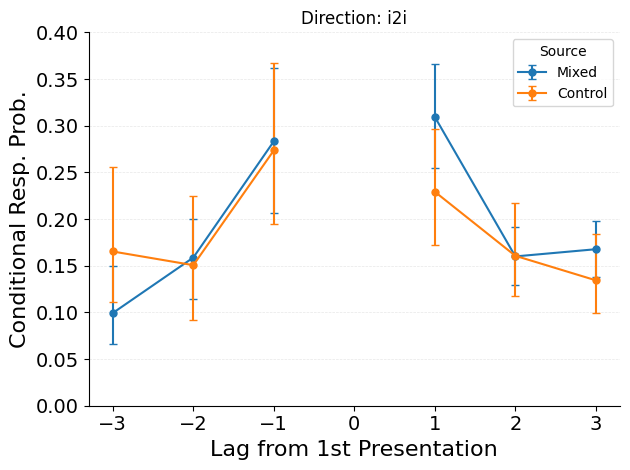

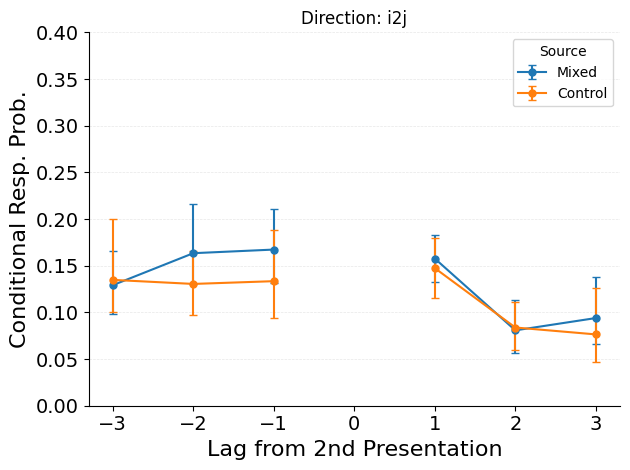

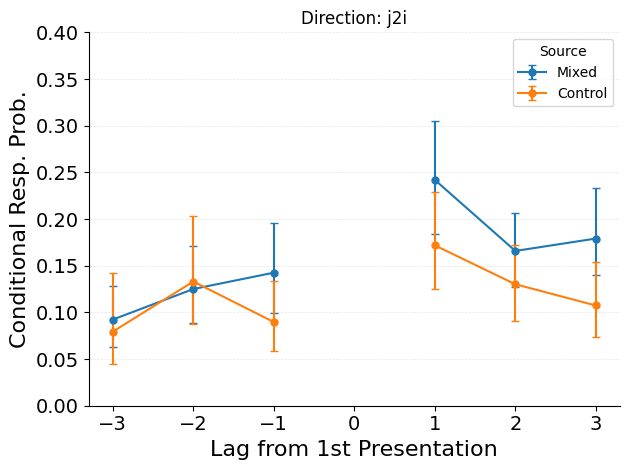

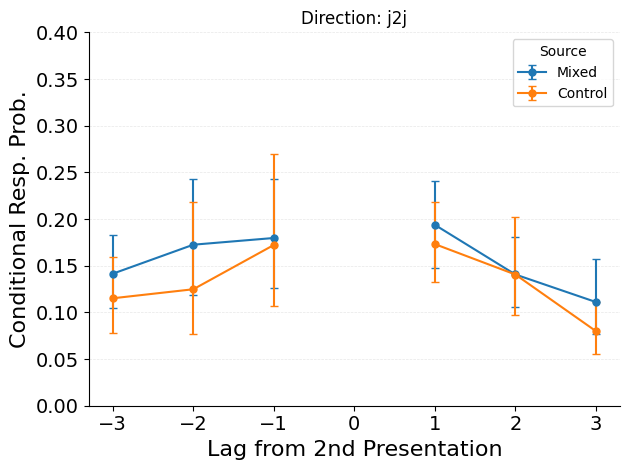

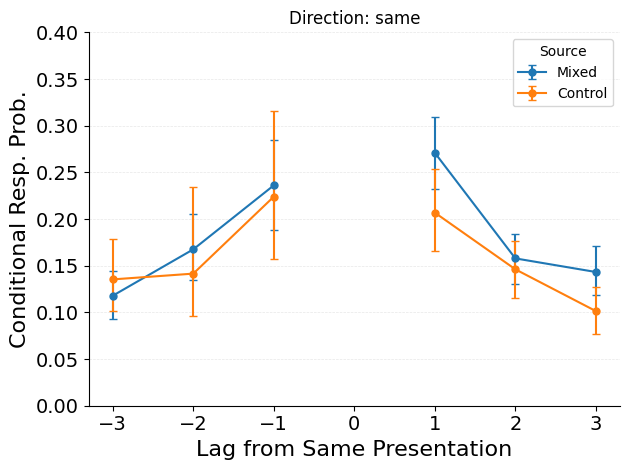

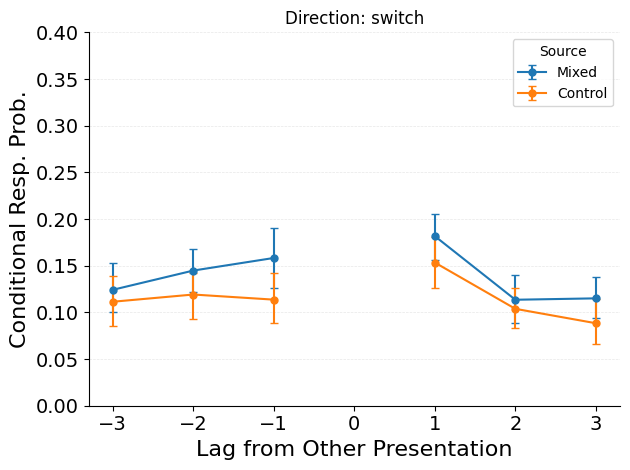

In [4]:
for direction in directions:
    plot_rep_route_crp(
        datasets=datasets,
        trial_masks=masks,
        max_lag=max_lag,
        min_lag=min_lag,
        direction=direction,
        use_lag2=use_lag2,
        contrast_name="Source",
        labels=["Mixed", "Control"],
    )
    plt.title(f"Direction: {direction}")
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    save_figure(figure_dir, figure_str, suffix=direction)

In [5]:
for direction in directions:
    observed_crp = subject_rep_route_crp(
        data, trial_mask, direction, use_lag2, min_lag, max_lag
    )
    control_crp = subject_rep_route_crp(
        control_dataset, control_mask, direction, use_lag2, min_lag, max_lag
    )

    result = test_rep_route_crp_vs_control(observed_crp, control_crp, max_lag, direction)

    print(f"\n{'='*70}")
    print(f"Statistical Test: {direction}")
    print(f"{'='*70}")
    if direction == "same":
        print("Tests whether same-route continuations through the repeater are elevated vs control.")
    elif direction == "switch":
        print("Tests whether switch-route continuations through the repeater are elevated vs control.")
    else:
        print("Tests one incoming-route/outgoing-center combination vs control.")
    print()
    print(result)

observed_same = subject_rep_route_crp(
    data, trial_mask, "same", use_lag2, min_lag, max_lag
)
observed_switch = subject_rep_route_crp(
    data, trial_mask, "switch", use_lag2, min_lag, max_lag
)
control_same = subject_rep_route_crp(
    control_dataset, control_mask, "same", use_lag2, min_lag, max_lag
)
control_switch = subject_rep_route_crp(
    control_dataset, control_mask, "switch", use_lag2, min_lag, max_lag
)
bias_result = test_same_switch_bias(
    observed_same, observed_switch, control_same, control_switch, max_lag
)

print(f"\n{'='*70}")
print("Test: Same-Switch Bias (Observed) vs Same-Switch Bias (Control)")
print(f"{'='*70}")
print(bias_result)

/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/reproutecrp.py:731: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/reproutecrp.py:742: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)



Statistical Test: i2i
Tests one incoming-route/outgoing-center combination vs control.

Direction: i2i
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |   -1.820     0.0775 |    118.0     0.0879 |    -0.0659
   -2 |    0.315     0.7547 |    195.0     0.8553 |     0.0128
   -1 |    0.193     0.8483 |    163.0     0.7508 |     0.0122
    0 |      nan        nan |      nan        nan |        nan
    1 |    2.432     0.0204 |    152.0     0.0129 |     0.0801
    2 |   -0.024     0.9811 |    260.0     0.7141 |    -0.0007
    3 |    1.321     0.1954 |    178.5     0.0418 |     0.0333



Statistical Test: i2j
Tests one incoming-route/outgoing-center combination vs control.

Direction: i2j
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |   -0.175     0.8623 |    240.5     0.8831 |    -0.0057
   -2 |    1.201     0.2381 |    230.5     0.3714 |     0.0329
   -1 |    1.052     0.3002 |    188.5     0.1002 |     0.0339
    0 |      nan        nan |      nan        nan |        nan
    1 |    0.438     0.6642 |    264.5     0.5726 |     0.0102
    2 |   -0.165     0.8700 |    207.5     0.8288 |    -0.0030
    3 |    0.707     0.4845 |    138.0     0.2204 |     0.0175



Statistical Test: j2i
Tests one incoming-route/outgoing-center combination vs control.

Direction: j2i
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    0.427     0.6720 |    134.0     0.2918 |     0.0129
   -2 |   -0.293     0.7710 |    159.0     0.6751 |    -0.0080
   -1 |    1.914     0.0640 |    124.5     0.0737 |     0.0529
    0 |      nan        nan |      nan        nan |        nan
    1 |    2.621     0.0130 |     87.5     0.0085 |     0.0701
    2 |    1.238     0.2241 |    204.0     0.2618 |     0.0357
    3 |    2.173     0.0368 |    157.0     0.0454 |     0.0717



Statistical Test: j2j
Tests one incoming-route/outgoing-center combination vs control.

Direction: j2j
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    0.798     0.4306 |    228.5     0.3527 |     0.0263
   -2 |    0.822     0.4169 |    118.5     0.3679 |     0.0381
   -1 |    0.070     0.9446 |    172.5     0.9392 |     0.0034
    0 |      nan        nan |      nan        nan |        nan
    1 |    0.605     0.5493 |    236.5     0.6071 |     0.0206
    2 |    0.001     0.9995 |    210.0     0.6435 |     0.0000
    3 |    1.311     0.1988 |    130.0     0.3818 |     0.0288



Statistical Test: same
Tests whether same-route continuations through the repeater are elevated vs control.

Direction: same
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |   -0.729     0.4709 |    258.0     0.4995 |    -0.0175
   -2 |    0.634     0.5305 |    193.0     0.1843 |     0.0260
   -1 |    0.256     0.7991 |    219.5     0.5764 |     0.0121
    0 |      nan        nan |      nan        nan |        nan
    1 |    2.950     0.0057 |    153.0     0.0135 |     0.0641
    2 |    0.669     0.5078 |    240.0     0.4692 |     0.0117
    3 |    2.595     0.0139 |    128.0     0.0064 |     0.0419



Statistical Test: switch
Tests whether switch-route continuations through the repeater are elevated vs control.

Direction: switch
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |    0.711     0.4822 |    233.0     0.5621 |     0.0128
   -2 |    1.611     0.1164 |    194.0     0.1222 |     0.0257
   -1 |    2.049     0.0482 |    158.5     0.0293 |     0.0446
    0 |      nan        nan |      nan        nan |        nan
    1 |    1.759     0.0876 |    214.0     0.1002 |     0.0283
    2 |    0.606     0.5483 |    251.0     0.5981 |     0.0097
    3 |    1.767     0.0863 |    166.5     0.0417 |     0.0267



Test: Same-Switch Bias (Observed) vs Same-Switch Bias (Control)
Direction: same-switch
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -3 |   -1.421     0.1644 |    215.0     0.1584 |    -0.0302
   -2 |    0.008     0.9935 |    245.0     0.3694 |     0.0004
   -1 |   -0.789     0.4353 |    255.0     0.4675 |    -0.0325
    0 |      nan        nan |      nan        nan |        nan
    1 |    1.595     0.1199 |    212.0     0.0934 |     0.0358
    2 |    0.085     0.9325 |    292.0     0.9251 |     0.0020
    3 |    0.820     0.4182 |    202.0     0.2463 |     0.0152


## Interpretation

Plots show transition probabilities after recall reaches a repeated item from a predecessor-side occurrence-specific route. Key patterns:

- **Route preservation**: elevated same-route continuations indicate that recall of the repeated item preserves the predecessor-side occurrence route.
- **Route switching**: elevated switch-route continuations indicate that the repeated item acts as a bridge into the other occurrence's neighborhood.
- **Observed vs. control**: differences isolate repetition-specific route effects beyond shuffled baselines.
- **Same-switch bias**: a positive same-switch difference suggests that the repeated item is not simply erasing the incoming route.

## API Details

### Notebook parameters

- `data_path` - path to an HDF5 file containing a `RecallDataset` with repeated items.
- `figure_dir` - directory for saving figures.
- `figure_str` - base filename for saved figures. Leave empty to display without saving.
- `ylim` - y-axis limits as a tuple, or `None` for automatic scaling.
- `mixed_trial_query` - selects trials containing repeated items.
- `control_trial_query` - selects pure control trials for the shuffled control.
- `control_shuffles` - number of shuffled control blocks per subject.
- `min_lag` - minimum spacing between repeated presentations.
- `max_lag` - maximum lag to display on the x-axis.
- `use_lag2` - whether incoming routes include -2 predecessor-side neighbors as well as -1 neighbors.
- `directions` - route-conditioned transitions to plot and test.

### Directions

- `i2i` - i predecessor-side neighbor -> repeater -> lags centered on i.
- `i2j` - i predecessor-side neighbor -> repeater -> lags centered on j.
- `j2i` - j predecessor-side neighbor -> repeater -> lags centered on i.
- `j2j` - j predecessor-side neighbor -> repeater -> lags centered on j.
- `same` - count-combined i2i and j2j.
- `switch` - count-combined i2j and j2i.
- `both` - full 2 x 2 route matrix.